In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
#LOAD & FIX FILE
file = r"C:\AI&ML Project\1774806157_well-1343E.csv"

In [7]:
# Read raw
df_raw = pd.read_csv(file, header=None)

In [9]:
# Extract correct header (row 1)
header = df_raw.iloc[1].values
df = df_raw.iloc[3:].copy()
df.columns = header



In [10]:

# Reset index
df = df.reset_index(drop=True)

In [11]:

# Convert to numeric
df = df.apply(pd.to_numeric, errors='coerce')

Cleaned Data:
       depth      dtco      sphi    rhom     hcgr  rock_type
0  103.5533  199.0909  0.597580  1.3836  32.2805          1
1  104.1000  198.7273  0.596066  1.5431  35.1178          1
2  106.0523  195.6364  0.583193  1.7525  33.9707          1
3  109.9571  195.6364  0.583193  1.7672  38.0664          1
4  111.9094  198.0000  0.593037  1.7249  40.8417          1


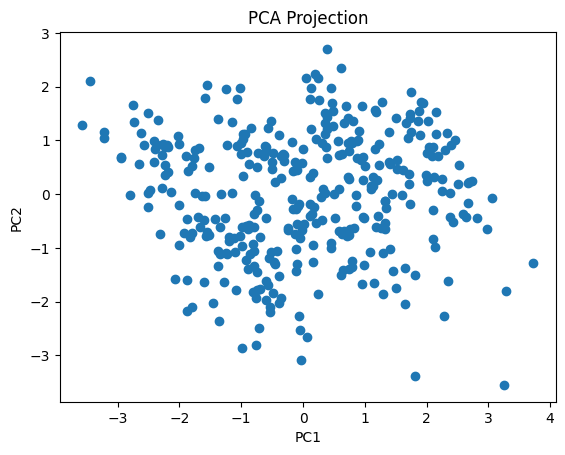

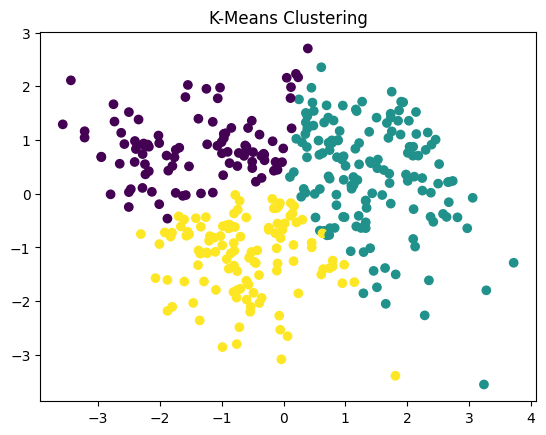

Reduction of Error: 0.9421487603305785


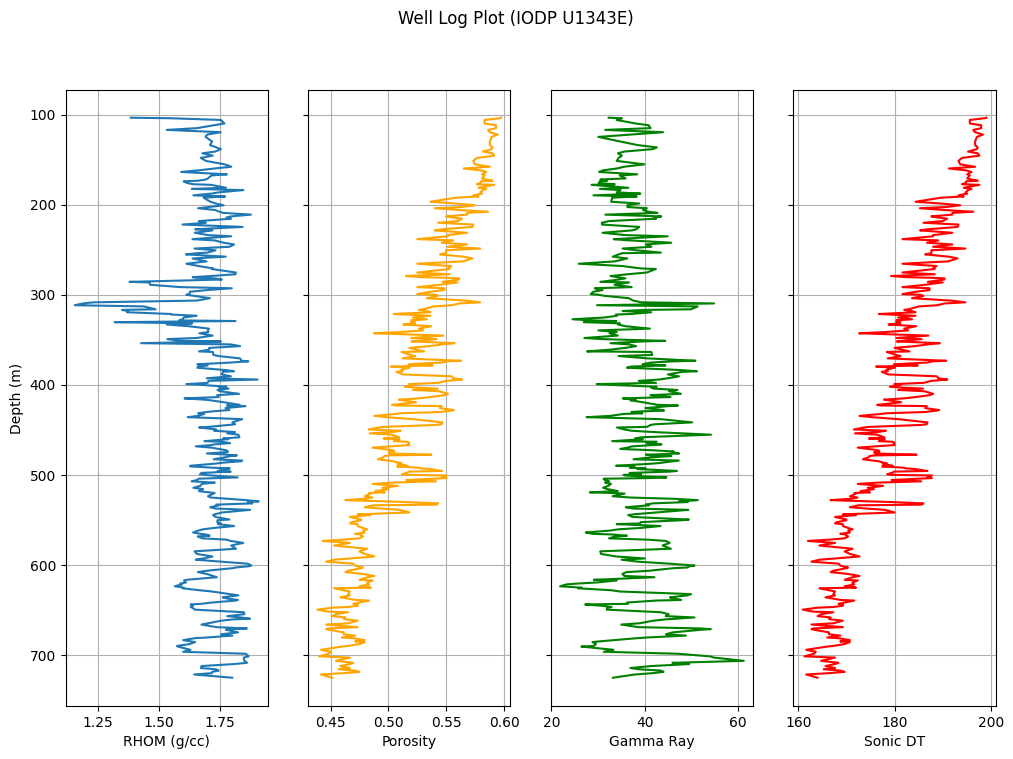

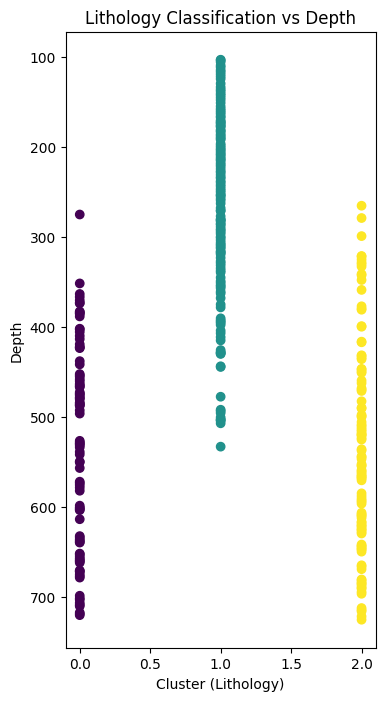

In [17]:
# Rename columns (clean)
df.rename(columns={
    'DEPTH': 'depth',
    'DTCO': 'dtco',
    'sphi': 'sphi',
    'RHOM': 'rhom',
    'HCGR': 'hcgr'
}, inplace=True)

# Drop NaN
df = df.dropna()

print("Cleaned Data:\n", df.head())


# ==============================
# STEP 2: ADD RESISTIVITY (NOT IN FILE)
# ==============================
# (Your dataset does not include resistivity → skip or simulate if needed)

logs = df[['rhom', 'sphi', 'hcgr', 'dtco']]


# ==============================
# STEP 3: NORMALIZATION
# ==============================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(logs)


# ==============================
# STEP 4: PCA
# ==============================
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1])
plt.title("PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


# ==============================
# STEP 5: K-MEANS
# ==============================
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=0)
clusters = kmeans.fit_predict(X_scaled)

plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.title("K-Means Clustering")
plt.show()


# ==============================
# STEP 6: SUPERVISED ML
# ==============================

df['rock_type'] = clusters

from sklearn.model_selection import train_test_split

X = df[['rhom', 'sphi', 'hcgr', 'dtco']]
y = df['rock_type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


# Random Forest
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


# ==============================
# STEP 7: REDUCTION OF ERROR
# ==============================
def RE(y_true, y_pred):
    return 1 - (np.sum((y_pred - y_true)**2) / np.sum(y_true**2))

print("Reduction of Error:", RE(y_test, y_pred))


# ==============================
# STEP 8: PROFESSIONAL WELL LOG PLOT
# ==============================

depth = df['depth']

fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(12,8), sharey=True)

# RHOM
ax[0].plot(df['rhom'], depth)
ax[0].set_xlabel("RHOM (g/cc)")
ax[0].set_ylabel("Depth (m)")
ax[0].invert_yaxis()
ax[0].grid()

# SPHI
ax[1].plot(df['sphi'], depth,color="orange")
ax[1].set_xlabel("Porosity")
ax[1].grid()

# HCGR
ax[2].plot(df['hcgr'], depth,color="green")
ax[2].set_xlabel("Gamma Ray")
ax[2].grid()

# DTCO
ax[3].plot(df['dtco'], depth,color="red")
ax[3].set_xlabel("Sonic DT")
ax[3].grid()

plt.suptitle("Well Log Plot (IODP U1343E)")
plt.show()


# ==============================
# STEP 9: CLUSTER VS DEPTH
# ==============================

plt.figure(figsize=(4,8))
plt.scatter(df['rock_type'], depth, c=df['rock_type'])
plt.gca().invert_yaxis()
plt.xlabel("Cluster (Lithology)")
plt.ylabel("Depth")
plt.title("Lithology Classification vs Depth")
plt.show()